# Section 1: Data Loading & Cleaning


### Import Neccessary Libraries

In [1]:
import datetime
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from scipy import stats

# ====================== DISPLAY SETTINGS ======================
pd.options.display.float_format = "{:,.6f}".format   # 6 decimal places + thousand separators
pd.set_option('display.max_columns', None)           # Show all columns
pd.set_option('display.width', 1000)                 # Wider display
pd.set_option('display.max_rows', 100)               # Adjust as needed
# ============================================================

sns.set_style("whitegrid")   # Clean plotting style
sns.set()

### Data Loading, Cleaning and Conversion into CSV files

In [2]:
# Dangote Cement Stock Price
dangcem = pd.read_csv("../data/raw/Dangote Cement Stock Price History.csv", index_col="Date") 
dangcem.drop(columns=["Open", "High", "Low", "Vol.", "Change %"], inplace=True)
dangcem.rename(columns={"Price":"DANGCEM"}, inplace=True)
# Covert str => float
dangcem["DANGCEM"] = dangcem["DANGCEM"].str.replace(",","").astype("float64")

# Guaranty Trust Holding Stock Price
gtco = pd.read_csv("../data/raw/Guaranty Trust Holding Stock Price History.csv", index_col="Date") 
gtco.drop(columns=["Open", "High", "Low", "Vol.", "Change %"], inplace=True)
gtco.rename(columns={"Price":"GTCO"}, inplace=True)

# Zenith Bank Stock Price
zenith = pd.read_csv("../data/raw/Zenith Bank Stock Price History.csv", index_col="Date") 
zenith.drop(columns=["Open", "High", "Low", "Vol.", "Change %"], inplace=True)
zenith.rename(columns={"Price":"ZENITHB"}, inplace=True)

In [3]:
stock_prices = pd.concat([dangcem, gtco, zenith], axis=1)
stock_prices.to_csv("../data/processed/Dangcem_Gtco_Zenithb.csv", index=True)

### Loading the CSV file I created.

In [4]:
start = pd.Timestamp("2021-06-21").tz_localize(None)
end = pd.Timestamp("2026-06-21").tz_localize(None)

prices = pd.read_csv("../data/processed/Dangcem_Gtco_Zenithb.csv", index_col="Date", parse_dates=True)

prices.index = pd.to_datetime(prices.index)
prices = prices.sort_index()

prices = prices.loc[start:end]
# prices = prices[prices.index.dayofweek < 5]
prices.head()

,DANGCEM,GTCO,ZENITHB
Date,,,
2021-06-21,230.000000,NaN,23.900000
2021-06-22,230.000000,NaN,23.800000
2021-06-23,230.000000,NaN,23.500000
2021-06-24,230.000000,28.550000,23.800000
2021-06-25,221.000000,30.000000,23.800000


# Section 2: Data Exploration & Quality Check

### Inspect data, handle missing values, plot prices.

In [5]:
prices.dropna(inplace=True)
prices.head()

,DANGCEM,GTCO,ZENITHB
Date,,,
2021-06-24,230.000000,28.550000,23.800000
2021-06-25,221.000000,30.000000,23.800000
2021-06-28,221.000000,30.000000,23.650000
2021-06-29,221.000000,30.000000,23.750000
2021-06-30,221.000000,29.900000,23.750000


In [6]:
prices.index.day_name().unique()

Index(['Thursday', 'Friday', 'Monday', 'Tuesday', 'Wednesday'], dtype='object', name='Date')

In [7]:
prices.describe()

,DANGCEM,GTCO,ZENITHB
count,"1,233.000000","1,233.000000","1,233.000000"
mean,440.033171,49.654298,41.803877
std,205.634692,31.400164,24.409544
min,220.000000,16.850000,18.830000
25%,273.500000,25.800000,24.550000
50%,360.000000,38.500000,34.430000
75%,577.000000,62.850000,47.950000
max,"1,180.000000",153.000000,135.900000


In [8]:
prices.dtypes

DANGCEM    float64
GTCO       float64
ZENITHB    float64
dtype: object

In [9]:
prices.isna().sum()

DANGCEM    0
GTCO       0
ZENITHB    0
dtype: int64

In [10]:
duplicates = prices.index[prices.index.duplicated()]
print(len(duplicates), "duplicate dates found")

0 duplicate dates found


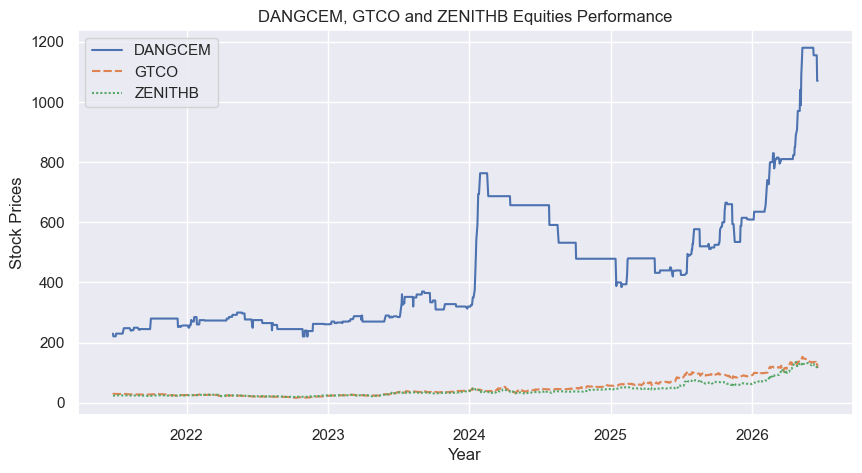

In [11]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=prices)
plt.xlabel("Year")
plt.ylabel("Stock Prices")
plt.title("DANGCEM, GTCO and ZENITHB Equities Performance")
plt.show()

# Section 3: Return Calculation & Analysis



### I) Computing returns for all three stocks.

In [12]:
#SIMPLE RETURNS
# simple_returns = prices.pct_change().iloc[1:]

# LOG RETURNS
returns = np.log(prices) - np.log(prices.shift(1))
returns.dropna(inplace=True)

returns.head()

,DANGCEM,GTCO,ZENITHB
Date,,,
2021-06-25,-0.039917,0.049540,0.000000
2021-06-28,0.000000,0.000000,-0.006322
2021-06-29,0.000000,0.000000,0.004219
2021-06-30,0.000000,-0.003339,0.000000
2021-07-01,0.000000,-0.013468,0.006296


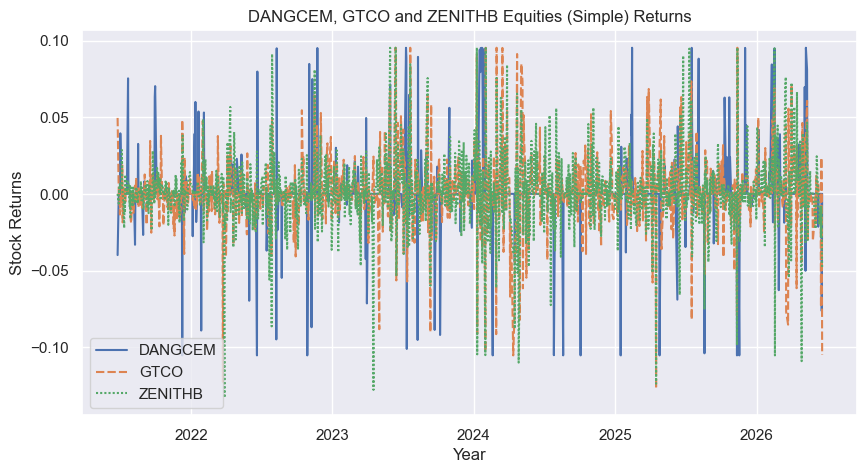

In [13]:
plt.figure(figsize=(10, 5))
sns.lineplot(returns)
plt.xlabel("Year")
plt.ylabel("Stock Returns")
plt.title("DANGCEM, GTCO and ZENITHB Equities (Simple) Returns")
plt.show()

### II) Annualized return and volatility.

#### Daily Return

In [14]:
summary_df = pd.DataFrame()

In [15]:
daily_return = returns.mean()
print("===========================")
print("Daily Average Return")
print("===========================")
print(daily_return)
print("===========================")
summary_df["DailyReturn"] = daily_return


Daily Average Return
DANGCEM   0.001248
GTCO      0.001135
ZENITHB   0.001243
dtype: float64


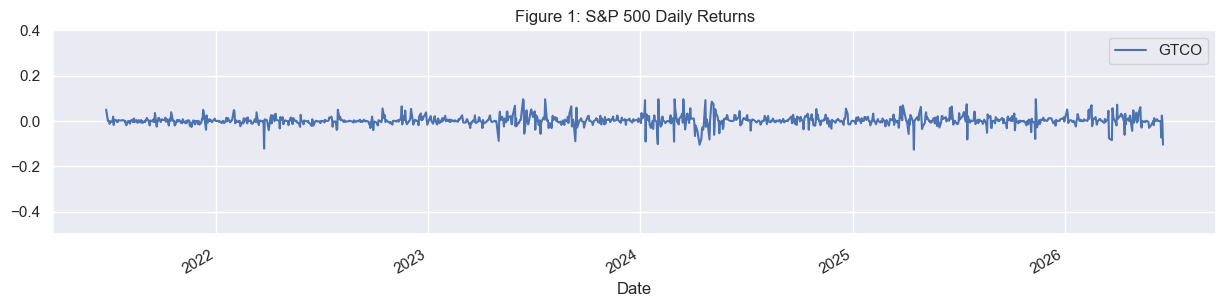

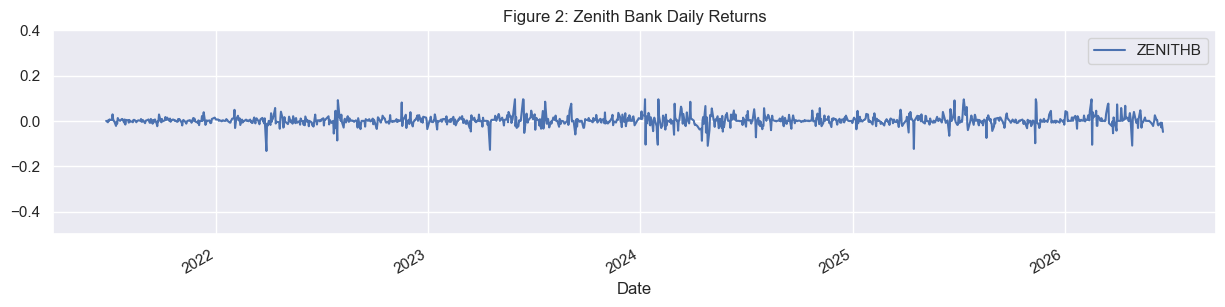

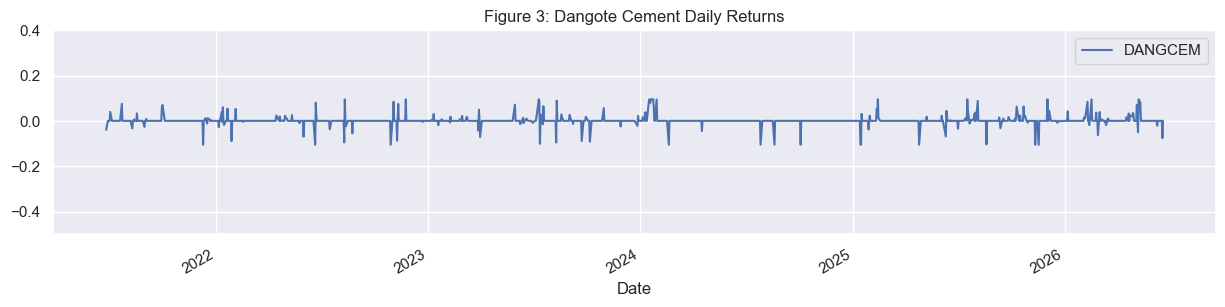

In [16]:
ax1 = returns.plot(figsize=(15, 3), y="GTCO", title="Figure 1: S&P 500 Daily Returns")
ax2 = returns.plot(figsize=(15, 3), y="ZENITHB", title="Figure 2: Zenith Bank Daily Returns")
ax3= returns.plot(figsize=(15, 3), y="DANGCEM", title="Figure 3: Dangote Cement Daily Returns")
# Set y-axis limits for both plots
ax1.set_ylim(-0.5, 0.4)
ax2.set_ylim(-0.5, 0.4)
ax3.set_ylim(-0.5, 0.4);


#### Annualized Return

In [17]:
# Using Log returns`
N = 252 # Trading days
annualized_return = np.prod(1+returns, axis=0)**(1/N) - 1 # Using Geometric Mean
annualized_return

DANGCEM   0.005021
GTCO      0.004365
ZENITHB   0.004811
dtype: float64

#### Volatility (Standard Deviation)

In [18]:
vols = returns.std()
summary_df["StandardDeviation"] = vols
print("===========================")
print("Volatility")
print("===========================")
print(vols)
print("===========================")

Volatility
DANGCEM   0.021055
GTCO      0.022032
ZENITHB   0.022772
dtype: float64


### III) Rolling volatility.

In [19]:
#  Rolling Volatility for 20- day

rolling_20 = (abs(prices - prices.rolling(20).mean())/prices).iloc[19:, :]
# rolling_20

#  Rolling Volatility for 50- day

rolling_50 = (abs(prices - prices.rolling(50).mean())/prices).iloc[49:, :]
# rolling_50.head()

#### 4. Moving Average Volatility


In [20]:
# 50-day Moving Average Volatility
moving_average_vol = rolling_20.mean()

# moving_average_vol = (abs(prices - prices.rolling(20).mean())/prices).mean()
print("===========================")
print("20-Day Moving Average")
print("===========================")

print(moving_average_vol)
print("==========================================")

# 50-day Moving Average Volatility
moving_average_vol = rolling_50.mean()
summary_df["MovingAverageVolatiliy"] = moving_average_vol
# moving_average_vol = (abs(prices - prices.rolling(50).mean())/prices).mean()
print("50-Day Moving Average")
print("===========================")
print(moving_average_vol)
print("===========================")


20-Day Moving Average
DANGCEM   0.037334
GTCO      0.040171
ZENITHB   0.039647
dtype: float64
50-Day Moving Average
DANGCEM   0.068414
GTCO      0.067471
ZENITHB   0.067712
dtype: float64


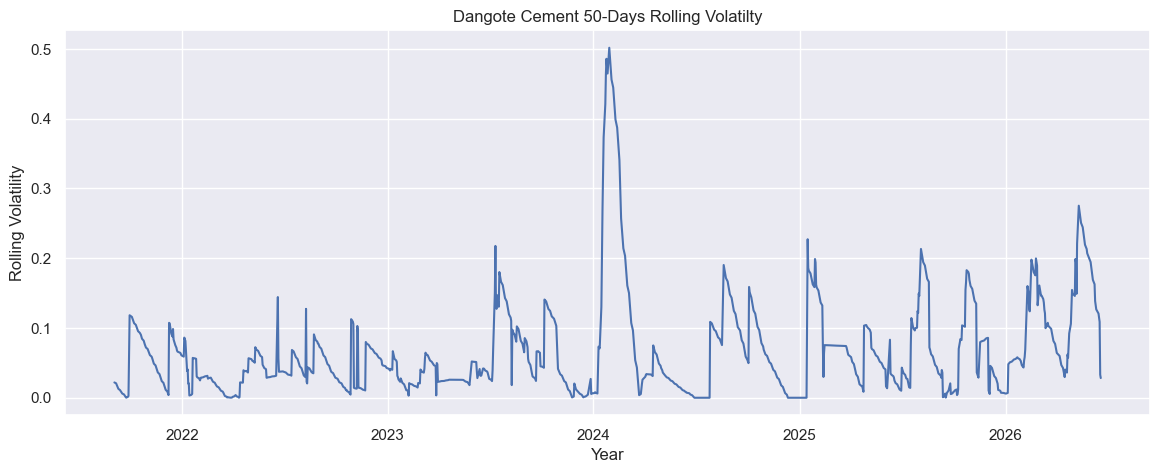

In [21]:
plt.figure(figsize=(14, 5))
sns.lineplot(x="Date", y="DANGCEM", data=rolling_50)
plt.xlabel("Year")
plt.ylabel("Rolling Volatility")
plt.title("Dangote Cement 50-Days Rolling Volatilty")
plt.show()

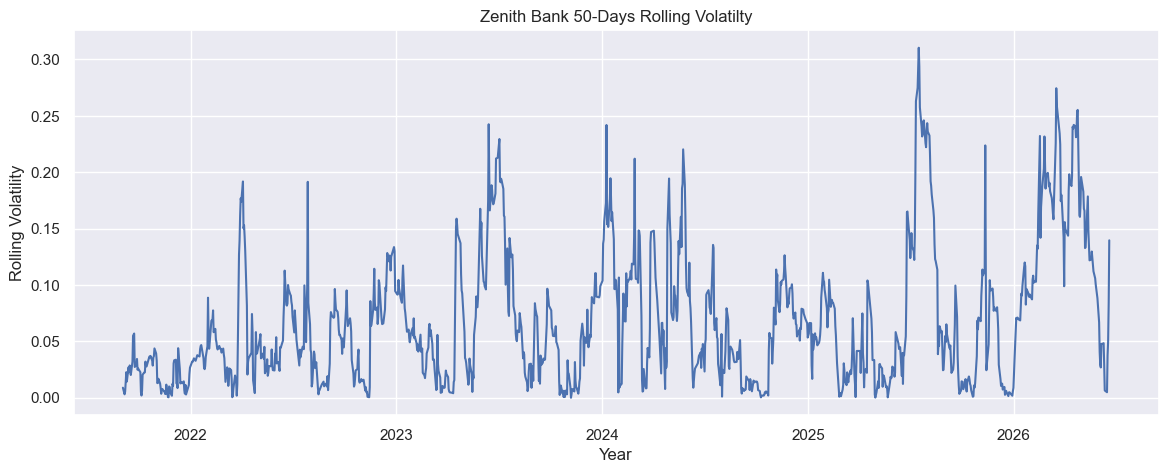

In [22]:
plt.figure(figsize=(14, 5))
sns.lineplot(x="Date", y="ZENITHB", data=rolling_50)
plt.xlabel("Year")
plt.ylabel("Rolling Volatility")
plt.title("Zenith Bank 50-Days Rolling Volatilty")
plt.show()

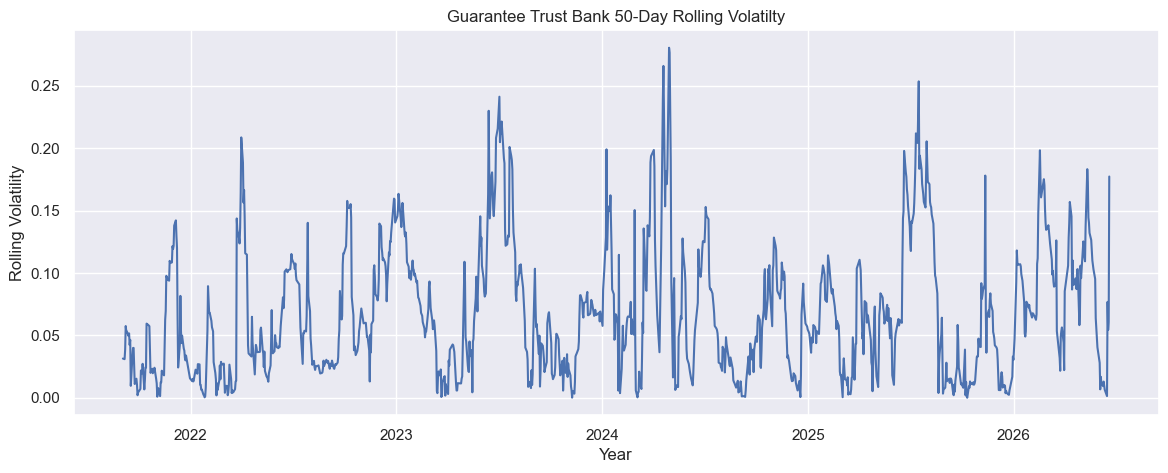

In [23]:
plt.figure(figsize=(14, 5))
sns.lineplot(x="Date", y="GTCO", data=rolling_50, legend=True)
plt.xlabel("Year")
plt.ylabel("Rolling Volatility")
plt.title("Guarantee Trust Bank 50-Day Rolling Volatilty")
plt.show()

#### 5. Sharpe Ratio

In [24]:
# Assuming it is a zero riskfree rate
sharpe_ratio = returns.mean()/returns.std()
summary_df["Sharpe Ratio"] = sharpe_ratio
print("===============================")
print("Sharpe Ratio")
print("===============================")
print(sharpe_ratio)
print("===============================")

Sharpe Ratio
DANGCEM   0.059266
GTCO      0.051507
ZENITHB   0.054563
dtype: float64


#### 6. Semi-variance (Deviation from Average Return)

In [25]:
semivariance = ((returns[returns < returns.mean()] - returns.mean())**2).mean()
summary_df["SemiVariance"]= semivariance
print(semivariance)
dangcem_mean = returns["DANGCEM"].mean()
gtco_mean = returns["GTCO"].mean()
zenithb_mean = returns["ZENITHB"].mean()

semivariance_dangcem = ((returns[returns['DANGCEM'] < dangcem_mean]['DANGCEM'] - dangcem_mean)**2).mean()
print("DANGCEM Cement:", semivariance_dangcem)
semivariance_gtco = ((returns[returns['GTCO'] < gtco_mean]['GTCO'] - gtco_mean)**2).mean()
print("GTCO Cement:", semivariance_gtco)
semivariance_zenithb = ((returns[returns['ZENITHB'] < zenithb_mean]['ZENITHB'] - zenithb_mean)**2).mean()
print("ZENITHB Cement:", semivariance_zenithb)

DANGCEM   0.000236
GTCO      0.000414
ZENITHB   0.000474
dtype: float64
DANGCEM Cement: 0.00023550550277426423
GTCO Cement: 0.0004144094034182309
ZENITHB Cement: 0.0004744306676422956


This output shows that ZENITHB has a much higher semivariance (0.000474) compared to the GTCO (0.000414) and DANGCEM (0.000236). This indicates that ZENITHB has experienced significantly larger negative deviations from its average return, suggesting higher downside risk.

### IV) High-Low range analysis.

In [26]:
start = pd.Timestamp(end - datetime.timedelta(365))
# start = end - pd.DateOffset(years=1)

In [27]:
currYear = prices.loc[start:end]

In [28]:
low = currYear.min()
high = currYear.max()
high_low = (high - low)/prices.iloc[-1, :]
summary_df["HighMinusLow"] = high_low
print("===============================")
print("High Minus Low Range Analysis")
print("===============================")
print(high_low)
print("===============================")

High Minus Low Range Analysis
DANGCEM   0.705607
GTCO      0.649070
ZENITHB   0.773182
dtype: float64


# Section 4: Matrix Analysis


### I) Covariance Matrix

In [29]:
covariance = returns.cov()
covariance

,DANGCEM,GTCO,ZENITHB
DANGCEM,0.000443,0.000014,0.000030
GTCO,0.000014,0.000485,0.000282
ZENITHB,0.000030,0.000282,0.000519


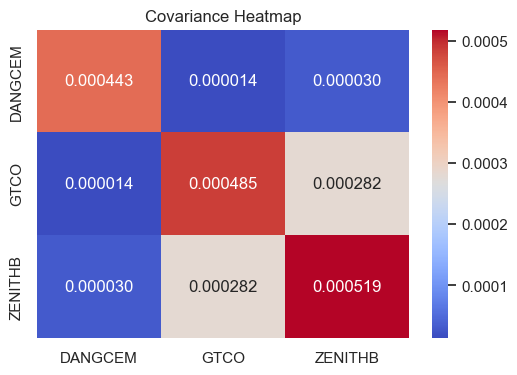

In [30]:
plt.figure(figsize=(6, 4))
sns.heatmap(
    covariance,
    annot=True,
    cmap="coolwarm",
    fmt=".6f",
    xticklabels=covariance.columns,
    yticklabels=covariance.columns
)
plt.title("Covariance Heatmap")
plt.show()


### II) Correlation Matrix

In [31]:
corr = returns.corr()
corr

,DANGCEM,GTCO,ZENITHB
DANGCEM,1.000000,0.030659,0.063382
GTCO,0.030659,1.000000,0.561799
ZENITHB,0.063382,0.561799,1.000000


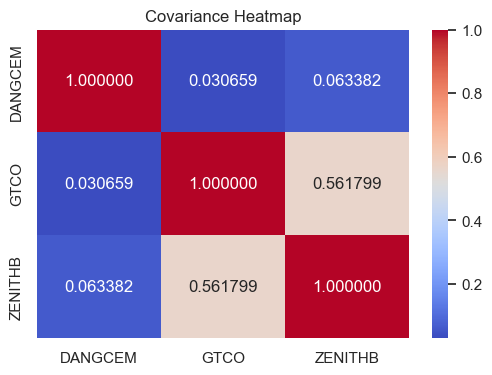

In [32]:
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".6f")
plt.title("Covariance Heatmap")
plt.show()

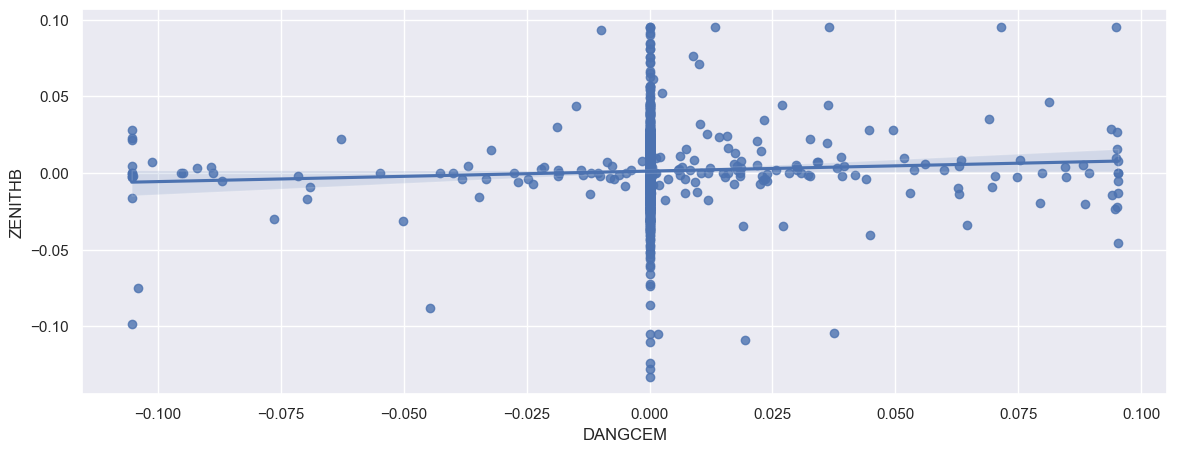

In [33]:
plt.figure(figsize=(14, 5))
sns.regplot(x='DANGCEM', y="ZENITHB", data=returns)
plt.show()

### III) Check for Symmetry & Positive Definiteness

In [34]:
# def is_symmetric(matrix):
#     if np.allclose(matrix, matrix.T):
#         return "Matrix is Symmetric matrix"
#     return "Matrix is a Non-Symmetric matrix"

In [35]:
# # Checks for Positive Definiteness
# def is_positive_definite(matrix):
#     eigvals = np.linalg.eigvals(matrix) # Eigen Valeus
#     det = np.linalg.det(matrix) # Determinant
#     if np.all(eigvals > 0) and np.all(det > 0):
#         return "Matrix is Positive Definite"
#     elif np.all(eigvals >= 0) and np.all(det >= 0):
#         return "Matrix is Semipositive Definite"
#     return "Matrix is neither Positive nor Semipositive Definite"

In [36]:
def is_symmetric_positive_definite(matrix):
    eigvals = np.linalg.eigvals(matrix) # Eigen Valeus
    det = np.linalg.det(matrix) # Determinant
    if np.allclose(matrix, matrix.T):
        if np.all(eigvals > 0) and np.all(det > 0):
            return "Matrix is a Symmetric Positive Definite Matrix"
        elif np.all(eigvals >= 0) and np.all(det >= 0):
            return "Matrix is a Symmetric Semipositive Definite"
    return "Matrix is neither Positive nor Semipositive Definite"    

In [37]:
is_symmetric_positive_definite(covariance)

'Matrix is a Symmetric Positive Definite Matrix'

### IV) Testing for Skewness

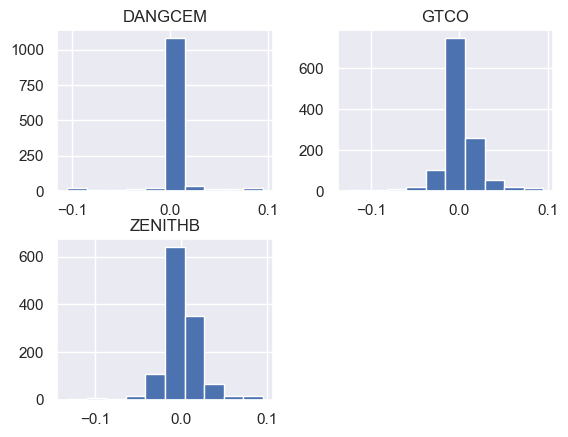

In [38]:
returns.hist(bins=10);

#### i) To determine how many data points we have on either side of the mean

The below code takes the count of data points greater than the mean and divides it by the total number of data points. This will give us the percentage of data points greater than the mean.



In [39]:
dangcem_skewness = (len(returns[returns.DANGCEM > returns.DANGCEM.mean()])) / (len(returns))
print("DANGCEM Skewness: ", dangcem_skewness)
gtco_skewness = (len(returns[returns.GTCO > returns.GTCO.mean()])) / (len(returns))
print("GTCO Skewness: ", gtco_skewness)
zenithb_skewness = (len(returns[returns.ZENITHB > returns.ZENITHB.mean()])) / (len(returns))
print("ZENITHB Skewness: ", zenithb_skewness)

DANGCEM Skewness:  0.09740259740259741
GTCO Skewness:  0.42045454545454547
ZENITHB Skewness:  0.45454545454545453


**Recall:** A value close to 0.5 suggests a roughly symmetrical distribution, while a value significantly greater than 0.5 suggests a negative skew (more returns below the mean).

#### ii) Conducting a Normality Test 
Using `normaltest()`

In [40]:
dangcem = stats.normaltest(np.array(returns.DANGCEM))
gtco = stats.normaltest(np.array(returns.GTCO))
zenithb = stats.normaltest(np.array(returns.ZENITHB))
print("==============================================================")
print("The Results of Normality")
print("==============================================================")
print("DANGCEM\npvalue = ", dangcem.pvalue, "\nstatistics =", dangcem.statistic)
print("==============================================================")
print("GTCO\npvalue = ", gtco.pvalue, "\nstatistics =", gtco.statistic)
print("==============================================================")
print("ZENITHB\npvalue = ", zenithb.pvalue, "\nstatistics =", zenithb.statistic)
print("==============================================================")

The Results of Normality
DANGCEM
pvalue =  1.8571603867423513e-62 
statistics = 284.2824542365081
GTCO
pvalue =  1.2142109941361424e-41 
statistics = 188.42378866889808
ZENITHB
pvalue =  5.428412269948837e-44 
statistics = 199.24419480038074


**Recall:**
- Statistic: A test statistic that measures the deviation from normality. Higher values indicate a greater deviation.
- p-value: The probability of observing the data if it were truly normally distributed. A small p-value (typically less than 0.05) suggests that the data is not normally distributed.

#### iii) Testing Skewness and Kurtosis 
Using `stats.jarque_bera()`
##### If **p_value < 0.05** indicates that the data is **not** normally distributed

In [41]:
dangcem_pvalue = stats.jarque_bera(np.array(returns.DANGCEM)).pvalue
gtco_pvalue = stats.jarque_bera(np.array(returns.GTCO)).pvalue
zenithb_pvalue = stats.jarque_bera(np.array(returns.ZENITHB)).pvalue
print("==============================================================")
print("P-values of Each Equity using Jarque_bera Normality Test")
print("==============================================================")
print("DANGCEM p_value:", dangcem_pvalue)
print("GTCO p_value:", gtco_pvalue)
print("ZENITHB p_value:", zenithb_pvalue)
print("==============================================================")

P-values of Each Equity using Jarque_bera Normality Test
DANGCEM p_value: 0.0
GTCO p_value: 0.0
ZENITHB p_value: 0.0


### iv) Does Our Gaussian Distribution Break Down?

In [42]:
# returns_max = returns.max()
# returns_min = returns.min()

#  Print maximum and minimum daily log returns
# num_dev_max = (returns_max - returns.mean())/returns.std()
# num_dev_min = (returns_min - returns.mean())/returns.std()

# Print maximum and minimum daily log returns
print("=================================================================================")
print("1. DANGCEM SAMPLE DATA")

return_max = returns["DANGCEM"].max()
return_min = returns["DANGCEM"].min()

num_dev_max = (return_max - returns["DANGCEM"].mean())/returns["DANGCEM"].std()
num_dev_min= (return_min - returns["DANGCEM"].mean())/returns["DANGCEM"].std()
print("=================================================================================")
print("Maximum return of DANGCEM sample data is: ", round(return_max, 5))
print("Minimum return of DANGCEM sample data is: ", round(return_min, 5))
print("=================================================================================")

# Print num_dev_max and num_dev_min
print("Number of standard deviations from the mean for the maximum return: ", round(num_dev_max, 5))
print("Number of standard deviations from the mean for the minimum return: ", round(num_dev_min, 5))
print("=================================================================================\n")


print("2. GTCO SAMPLE DATA")

return_max = returns["GTCO"].max()
return_min = returns["GTCO"].min()

num_dev_max = (return_max - returns["GTCO"].mean())/returns["GTCO"].std()
num_dev_min= (return_min - returns["GTCO"].mean())/returns["GTCO"].std()
print("=================================================================================")
print("Maximum return of GTCO sample data is: ", round(return_max, 5))
print("Minimum return of GTCO sample data is: ", round(return_min, 5))
print("=================================================================================")

# Print num_dev_max and num_dev_min
print("Number of standard deviations from the mean for the maximum return: ", round(num_dev_max, 5))
print("Number of standard deviations from the mean for the minimum return: ", round(num_dev_min, 5))
print("=================================================================================\n")

print("3. ZENITHB SAMPLE DATA")

return_max = returns["ZENITHB"].max()
return_min = returns["ZENITHB"].min()

num_dev_max = (return_max - returns["ZENITHB"].mean())/returns["ZENITHB"].std()
num_dev_min= (return_min - returns["ZENITHB"].mean())/returns["ZENITHB"].std()
print("=================================================================================")
print("Maximum return of ZENITHB sample data is: ", round(return_max, 5))
print("Minimum return of ZENITHB sample data is: ", round(return_min, 5))
print("=================================================================================")

# Print num_dev_max and num_dev_min
print("Number of standard deviations from the mean for the maximum return: ", round(num_dev_max, 5))
print("Number of standard deviations from the mean for the minimum return: ", round(num_dev_min, 5))
print("=================================================================================\n")

1. DANGCEM SAMPLE DATA
Maximum return of DANGCEM sample data is:  0.09531
Minimum return of DANGCEM sample data is:  -0.10536
Number of standard deviations from the mean for the maximum return:  4.4675
Number of standard deviations from the mean for the minimum return:  -5.06337

2. GTCO SAMPLE DATA
Maximum return of GTCO sample data is:  0.09531
Minimum return of GTCO sample data is:  -0.12716
Number of standard deviations from the mean for the maximum return:  4.27456
Number of standard deviations from the mean for the minimum return:  -5.823

3. ZENITHB SAMPLE DATA
Maximum return of ZENITHB sample data is:  0.09531
Minimum return of ZENITHB sample data is:  -0.133
Number of standard deviations from the mean for the maximum return:  4.13079
Number of standard deviations from the mean for the minimum return:  -5.895



In [43]:
stats.norm.cdf(-0.105361)

np.float64(0.458044680630599)

In [44]:
summary_df

,DailyReturn,StandardDeviation,MovingAverageVolatiliy,Sharpe Ratio,SemiVariance,HighMinusLow
DANGCEM,0.001248,0.021055,0.068414,0.059266,0.000236,0.705607
GTCO,0.001135,0.022032,0.067471,0.051507,0.000414,0.649070
ZENITHB,0.001243,0.022772,0.067712,0.054563,0.000474,0.773182


### Similarity Measures

#### DANGCEM vs ZENITHB

In [45]:
stock_A = returns.DANGCEM
stock_B = returns.ZENITHB

# Euclidean Distance
euclidean_distance = np.sqrt(np.sum((stock_A - stock_B)**2))

# Manhattan Distance
manhattan_distance = np.sum(np.abs(stock_A-stock_B))

# Euclidean Distance Cosine Similarity
dot_product = np.dot(stock_A, stock_B)
magnitude_A = np.linalg.norm(stock_A)
magnitude_B = np.linalg.norm(stock_B)
cosine_similarity = dot_product / (magnitude_A * magnitude_B)

DANGCEM_ZENITH_similarity_measures = pd.DataFrame(
    {
        "Euclidean Distance": euclidean_distance,
        "Manhattan Distance": manhattan_distance,
        "Cosine Similarity": cosine_similarity
    }, index=["DANGCEM - ZENITHBANK"]
)

In [46]:
DANGCEM_ZENITH_similarity_measures

,Euclidean Distance,Manhattan Distance,Cosine Similarity
DANGCEM - ZENITHBANK,1.053214,22.215521,0.066403


#### DANGCEM vs GTCO

In [47]:
stock_A = returns.DANGCEM
stock_B = returns.GTCO

# Euclidean Distance
euclidean_distance = np.sqrt(np.sum((stock_A - stock_B)**2))

# Manhattan Distance
manhattan_distance = np.sum(np.abs(stock_A-stock_B))

# Euclidean Distance Cosine Similarity
dot_product = np.dot(stock_A, stock_B)
magnitude_A = np.linalg.norm(stock_A)
magnitude_B = np.linalg.norm(stock_B)
cosine_similarity = dot_product / (magnitude_A * magnitude_B)

DANGCEM_GTCO_similarity_measures = pd.DataFrame(
    {
        "Euclidean Distance": euclidean_distance,
        "Manhattan Distance": manhattan_distance,
        "Cosine Similarity": cosine_similarity
    }, index=["DANGCEM - GTCO"]
)

#### ZENITHBANK vs GTCO

In [48]:
stock_A = returns.ZENITHB
stock_B = returns.GTCO

# Euclidean Distance
euclidean_distance = np.sqrt(np.sum((stock_A - stock_B)**2))

# Manhattan Distance
manhattan_distance = np.sum(np.abs(stock_A-stock_B))

# Euclidean Distance Cosine Similarity
dot_product = np.dot(stock_A, stock_B)
magnitude_A = np.linalg.norm(stock_A)
magnitude_B = np.linalg.norm(stock_B)
cosine_similarity = dot_product / (magnitude_A * magnitude_B)

ZENITHBANK_GTCO_similarity_measures = pd.DataFrame(
    {
        "Euclidean Distance": euclidean_distance,
        "Manhattan Distance": manhattan_distance,
        "Cosine Similarity": cosine_similarity
    }, index=["ZENITHBANK - GTCO"]
)

In [49]:
# similarity_measures
similarity_measures = pd.concat(
    [
        DANGCEM_ZENITH_similarity_measures,
        DANGCEM_GTCO_similarity_measures,
        ZENITHBANK_GTCO_similarity_measures
    ],
    axis=0
)

In [50]:
similarity_measures

,Euclidean Distance,Manhattan Distance,Cosine Similarity
DANGCEM - ZENITHBANK,1.053214,22.215521,0.066403
DANGCEM - GTCO,1.052723,21.788254,0.033610
ZENITHBANK - GTCO,0.736180,17.310483,0.563025
